Study of the features in Neural Networks. 

Train set accuracy = 0.3495767086516622
Test set accuracy  = 0.3435886846995664


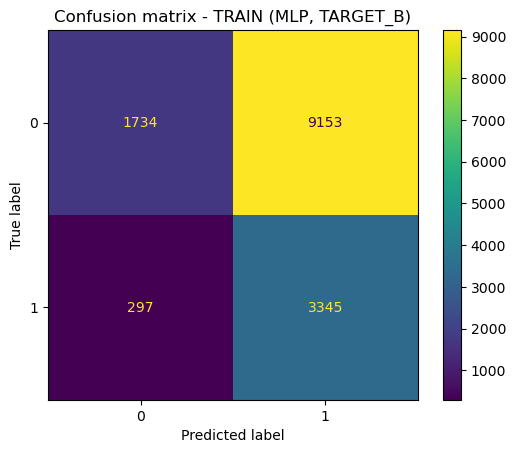

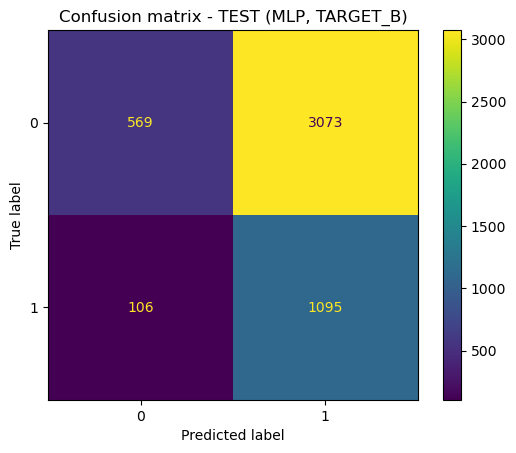

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.85      0.16      0.27     10887
           1       0.27      0.92      0.41      3642

    accuracy                           0.35     14529
   macro avg       0.56      0.54      0.34     14529
weighted avg       0.71      0.35      0.31     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.84      0.16      0.26      3642
           1       0.26      0.91      0.41      1201

    accuracy                           0.34      4843
   macro avg       0.55      0.53      0.34      4843
weighted avg       0.70      0.34      0.30      4843



In [1]:
### Here I started by using only the complete numerical features.
# Results: Very bad results.
# Next we will try standartizing the full data, as we've seen in classes. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt



df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
]

# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
#print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=500, random_state=0)
mlp_B.fit(X_B_train, y_B_train)

print("Train set accuracy =", mlp_B.score(X_B_train, y_B_train))
print("Test set accuracy  =", mlp_B.score(X_B_test, y_B_test))

# Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train)
y_B_test_pred  = mlp_B.predict(X_B_test)

cm_train = confusion_matrix(y_B_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))


Train set accuracy = 0.8136829788698465
Test set accuracy  = 0.6977080322114392


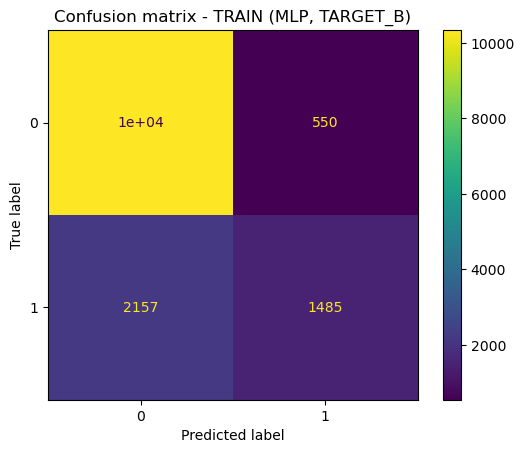

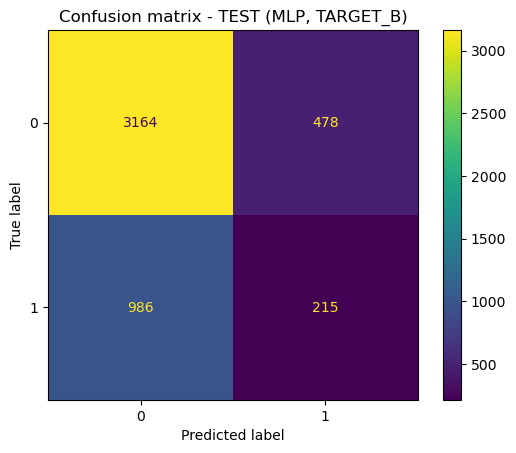

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.88     10887
           1       0.73      0.41      0.52      3642

    accuracy                           0.81     14529
   macro avg       0.78      0.68      0.70     14529
weighted avg       0.80      0.81      0.79     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      3642
           1       0.31      0.18      0.23      1201

    accuracy                           0.70      4843
   macro avg       0.54      0.52      0.52      4843
weighted avg       0.65      0.70      0.67      4843



In [12]:
### Neural network with standartized data. 
# Results: A big improvement. I will keep using standartized data from now on. Still a lot of overfitting. 
# Next will try to add the complete categorical data. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

df_donors = pd.read_csv('Donors_dataset.csv')

label_balance = 'balanced'

num_features = num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]

cat_features = [
]

# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
#print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

# Standardize features (as in TP12)
sc = StandardScaler()
sc.fit(X_B_train)
X_B_train_std = sc.transform(X_B_train)
X_B_test_std  = sc.transform(X_B_test)

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=500, random_state=0)
mlp_B.fit(X_B_train_std, y_B_train)

print("Train set accuracy =", mlp_B.score(X_B_train_std, y_B_train))
print("Test set accuracy  =", mlp_B.score(X_B_test_std, y_B_test))

# Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train_std)
y_B_test_pred  = mlp_B.predict(X_B_test_std)

cm_train = confusion_matrix(y_B_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

TARGET_B                      0
MONTHS_SINCE_ORIGIN           0
IN_HOUSE                      0
MOR_HIT_RATE                  0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PCT_OWNER_OCCUPIED            0
PER_CAPITA_INCOME             0
PCT_ATTRIBUTE1                0
PCT_ATTRIBUTE2                0
PCT_ATTRIBUTE3                0
PCT_ATTRIBUTE4                0
PEP_STAR                      0
RECENT_STAR_STATUS            0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
LIFETIME_GIFT_AMOUNT          0
LIFETIME_GIFT_COUNT           0
LIFETIME_AVG_GIFT_AMT         0
LIFETIME_GIFT_RANGE           0
LIFETIME_MAX_GIFT_AMT         0
LIFETIME_MIN_GIFT_AMT         0
LAST_GIFT_AMT                 0
CARD_PROM_12                  0
NUMBER_P

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


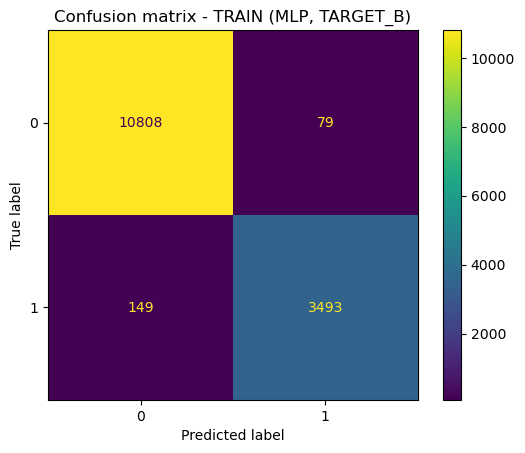

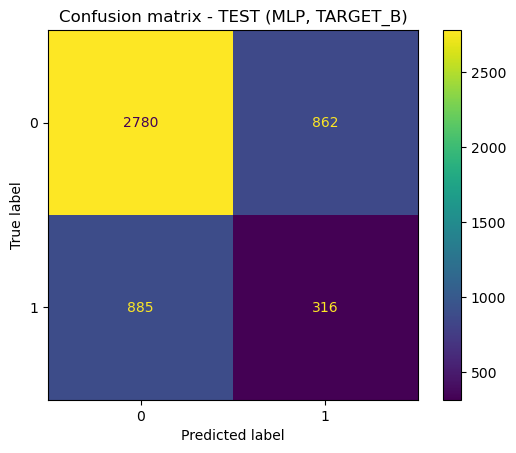

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10887
           1       0.98      0.96      0.97      3642

    accuracy                           0.98     14529
   macro avg       0.98      0.98      0.98     14529
weighted avg       0.98      0.98      0.98     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      3642
           1       0.27      0.26      0.27      1201

    accuracy                           0.64      4843
   macro avg       0.51      0.51      0.51      4843
weighted avg       0.64      0.64      0.64      4843



In [2]:
### Neural network with standartized data and including the categorical data. 
# Results: An improvement in the training results but a slight decrease for donor detection in the tes dataset.  
# Next we will try to balance the data. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

df_donors = pd.read_csv('Donors_dataset.csv')

df_donors

C = 100
penalty = 'l2' # or l1
solver = 'liblinear'

label_balance = 'balanced'

num_features = num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
    "URBANICITY",
    "SES",
    "CLUSTER_CODE",
    "HOME_OWNER",
    "DONOR_GENDER",
    "OVERLAY_SOURCE",
    "RECENCY_STATUS_96NK"
]


# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

# Standardize features (as in TP12)
sc = StandardScaler()
sc.fit(X_B_train)
X_B_train_std = sc.transform(X_B_train)
X_B_test_std  = sc.transform(X_B_test)

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=500, random_state=0)
mlp_B.fit(X_B_train_std, y_B_train)

print("Train set accuracy =", mlp_B.score(X_B_train_std, y_B_train))
print("Test set accuracy  =", mlp_B.score(X_B_test_std, y_B_test))

# Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train_std)
y_B_test_pred  = mlp_B.predict(X_B_test_std)

cm_train = confusion_matrix(y_B_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

Train set accuracy = 0.9843072475738179
Test set accuracy  = 0.6392731777823663


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


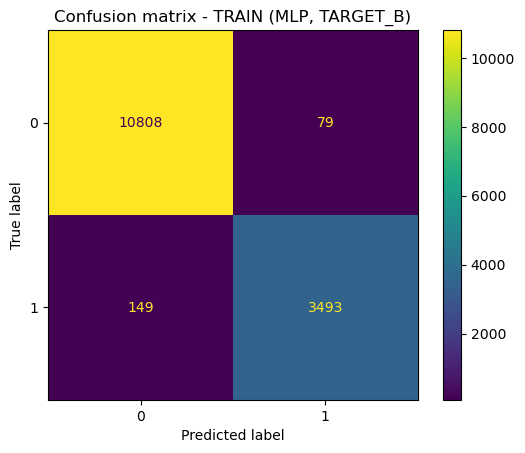

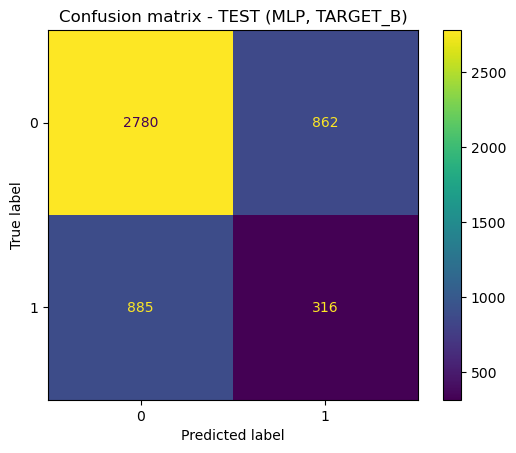

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10887
           1       0.98      0.96      0.97      3642

    accuracy                           0.98     14529
   macro avg       0.98      0.98      0.98     14529
weighted avg       0.98      0.98      0.98     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      3642
           1       0.27      0.26      0.27      1201

    accuracy                           0.64      4843
   macro avg       0.51      0.51      0.51      4843
weighted avg       0.64      0.64      0.64      4843



In [13]:
### Neural network with standartized data, categorical data. 
# Results: An improvement in the training results but a slight decrease for donor detection in the test dataset.  
# Next we will try to balance the data. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
    "URBANICITY",
    "SES",
    "CLUSTER_CODE",
    "HOME_OWNER",
    "DONOR_GENDER",
    "OVERLAY_SOURCE",
    "RECENCY_STATUS_96NK"
]


# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
#print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

# Standardize features (as in TP12)
sc = StandardScaler()
sc.fit(X_B_train)
X_B_train_std = sc.transform(X_B_train)
X_B_test_std  = sc.transform(X_B_test)

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=500, random_state=0)
mlp_B.fit(X_B_train_std, y_B_train)

print("Train set accuracy =", mlp_B.score(X_B_train_std, y_B_train))
print("Test set accuracy  =", mlp_B.score(X_B_test_std, y_B_test))

# Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train_std)
y_B_test_pred  = mlp_B.predict(X_B_test_std)

cm_train = confusion_matrix(y_B_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

TARGET_B                      0
MONTHS_SINCE_ORIGIN           0
IN_HOUSE                      0
MOR_HIT_RATE                  0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PCT_OWNER_OCCUPIED            0
PER_CAPITA_INCOME             0
PCT_ATTRIBUTE1                0
PCT_ATTRIBUTE2                0
PCT_ATTRIBUTE3                0
PCT_ATTRIBUTE4                0
PEP_STAR                      0
RECENT_STAR_STATUS            0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
LIFETIME_GIFT_AMOUNT          0
LIFETIME_GIFT_COUNT           0
LIFETIME_AVG_GIFT_AMT         0
LIFETIME_GIFT_RANGE           0
LIFETIME_MAX_GIFT_AMT         0
LIFETIME_MIN_GIFT_AMT         0
LAST_GIFT_AMT                 0
CARD_PROM_12                  0
NUMBER_P

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


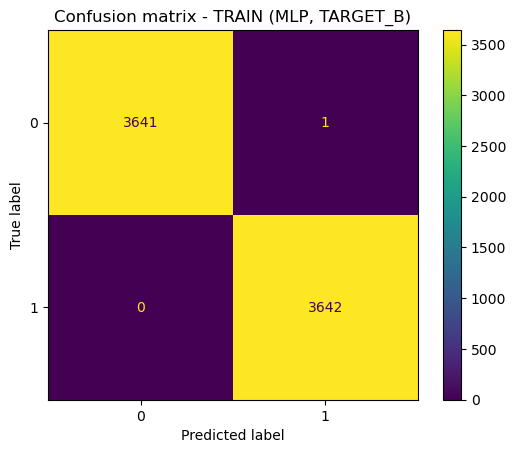

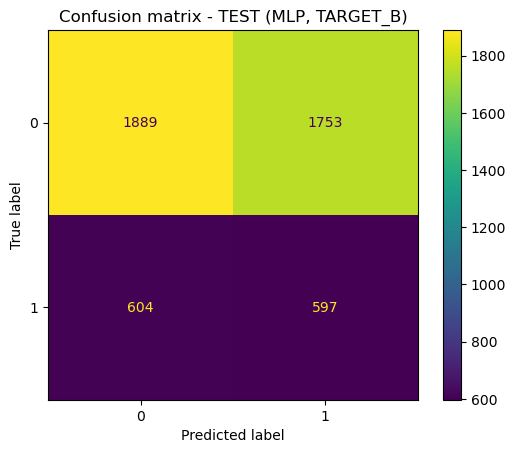

TRAIN classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3642
           1       1.00      1.00      1.00      3642

    accuracy                           1.00      7284
   macro avg       1.00      1.00      1.00      7284
weighted avg       1.00      1.00      1.00      7284

TEST classification report:
              precision    recall  f1-score   support

           0       0.76      0.52      0.62      3642
           1       0.25      0.50      0.34      1201

    accuracy                           0.51      4843
   macro avg       0.51      0.51      0.48      4843
weighted avg       0.63      0.51      0.55      4843



In [9]:
### Neural network with standartized data, categorical data and balanced data.
# The data was balanced by undersampling the non donors.  
# Results: It performs very well in the training dataset, but not so well in the test dataset. 
# Conclusion: Will probably need to experiment with the hyperparameters, in order to avoid overfitting and 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.utils import resample

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
    "URBANICITY",
    "SES",
    "CLUSTER_CODE",
    "HOME_OWNER",
    "DONOR_GENDER",
    "OVERLAY_SOURCE",
    "RECENCY_STATUS_96NK"
]


# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

train_df = pd.concat([X_B_train, y_B_train], axis=1)

train_non_donors = train_df[train_df['TARGET_B'] == 0]
train_donors = train_df[train_df['TARGET_B'] == 1]

# Undersampling non-donors.
train_non_donors_undersample = resample( # resample is a function from scikit-learn, used for this exact purpose. I will randomly select a number of non donors, to match the donors.
    train_non_donors,
    replace=False,
    n_samples=len(train_donors),
    random_state=42
)

# Concatenate to get balanced train set
train_balanced = pd.concat([train_non_donors_undersample, train_donors])

X_B_train_bal = train_balanced.drop('TARGET_B', axis=1)
y_B_train_bal = train_balanced['TARGET_B']

# Standardize features (as in TP12)
sc = StandardScaler()
sc.fit(X_B_train_bal)
X_B_train_std = sc.transform(X_B_train_bal)
X_B_test_std  = sc.transform(X_B_test)

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=500, random_state=0)
mlp_B.fit(X_B_train_std, y_B_train_bal)

print("Train set accuracy =", mlp_B.score(X_B_train_std, y_B_train_bal))
print("Test set accuracy  =", mlp_B.score(X_B_test_std, y_B_test))

# Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train_std)
y_B_test_pred  = mlp_B.predict(X_B_test_std)

cm_train = confusion_matrix(y_B_train_bal, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train_bal, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))
